# Análisis de Navegación Reactiva - Escenario Simple

Este notebook tiene como objetivo analizar los datos exportados por el controlador de Webots del robot e-puck. Estudiaremos cómo difieren las señales crudas (raw), las suavizadas por el filtro de promedio móvil (filtered) y la estimación calculada por el Filtro de Kalman.

In [1]:
%pip install pandas matplotlib numpy scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual de los gráficos
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carga de los Datos
Leemos los tres archivos CSV generados para el escenario simple:

In [4]:
# Cargar los datasets
df_raw = pd.read_csv('lab2_data_raw.csv')
df_filt = pd.read_csv('lab2_data_filtered.csv')
df_kalman = pd.read_csv('lab2_data_kalman.csv')

print("Tamaño Raw:", df_raw.shape)
print("Tamaño Filtered:", df_filt.shape)
print("Tamaño Kalman:", df_kalman.shape)

# Visualizar las primeras filas del dataset usando Kalman para navegación
print(df_kalman.head())

print(df_filt.head())

print(df_raw.head())

Tamaño Raw: (5000, 32)
Tamaño Filtered: (5000, 32)
Tamaño Kalman: (5000, 32)
   step  time_s nav_mode  raw_ps0  raw_ps7  raw_ps1  raw_ps6  raw_ps2  \
0     0   0.000   kalman    63.66    69.98    69.73    71.49    63.76   
1     1   0.064   kalman    67.79    67.07    68.71    69.97    71.73   
2     2   0.128   kalman    69.65    65.05    66.60    65.80    62.72   
3     3   0.192   kalman    62.82    70.81    67.04    68.08    64.97   
4     4   0.256   kalman    72.76    64.94    68.85    74.83    63.73   

   raw_ps5  dist_raw_front_R  ...  delta_right  delta_advance  \
0    66.77          0.120000  ...      0.00000       0.000000   
1    70.24          0.059598  ...      0.17584       0.003605   
2    69.75          0.058945  ...      0.18212       0.003669   
3    63.39          0.120000  ...      0.17584       0.003669   
4    64.21          0.057884  ...      0.17584       0.003605   

   kalman_prediction  kalman_estimate  kalman_gain  kalman_P  \
0           0.120000         

## 2. Comparación de las Señales (Cruda vs Promedio Móvil vs Kalman)
Durante el modo `kalman`, el robot de todos modos registró en cada instante las variables de los demás enfoques. Podemos visualizar esto extrayendo un fragmento de tiempo específico (por ejemplo los primeros 10-20 segundos o steps particulares) para ver cómo las tres lógicas perciben la **distancia frontal** de forma distinta.

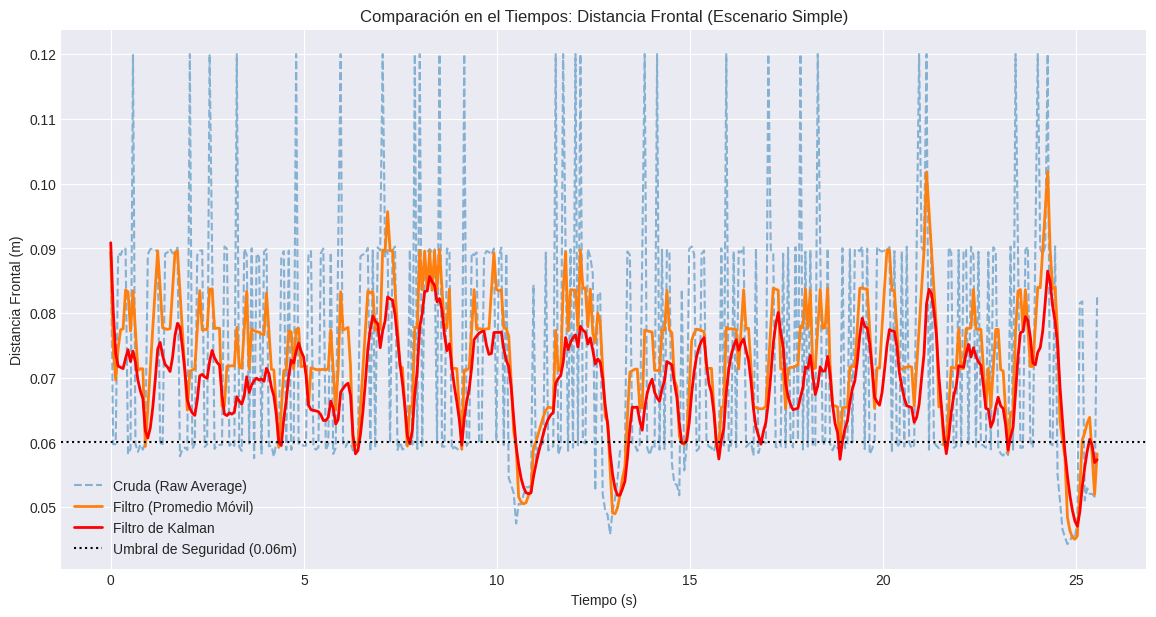

In [8]:
# Extraemos un segmento donde el robot interactúa (por ejemplo primeros 400 pasos)
segment_kalman = df_kalman.iloc[:400]

plt.figure(figsize=(14, 7))
plt.plot(segment_kalman['time_s'], segment_kalman['dist_raw_front_avg'], label='Cruda (Raw Average)', alpha=0.5, linestyle='--')
plt.plot(segment_kalman['time_s'], segment_kalman['dist_filtered_avg'], label='Filtro (Promedio Móvil)', linewidth=2)
plt.plot(segment_kalman['time_s'], segment_kalman['kalman_estimate'], label='Filtro de Kalman', linewidth=2, color='red')

plt.axhline(y=0.06, color='black', linestyle=':', label='Umbral de Seguridad (0.06m)')

plt.title('Comparación en el Tiempos: Distancia Frontal (Escenario Simple)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia Frontal (m)')
plt.legend()
plt.show()

## 3. Impacto de la Fusión en las Acciones de Navegación
Analizamos la cantidad de veces que el controlador debió aplicar acciones evasivas (`TURN_LEFT`, `TURN_RIGHT`) o si sufrió bloqueos (`STUCK`, `REVERSE`). En teoría, el filtro de Kalman, al estabilizar la señal temporal con los encoders, debería generar una conducción con *menos* oscilaciones y giros innecesarios.

,Raw,Filtered,Kalman
action,,,
FORWARD,35,190,150
FORWARD_CURVE_L,110,658,708
FORWARD_CURVE_R,381,2802,2711
TURN_LEFT,2151,783,837
TURN_RIGHT,2323,567,594


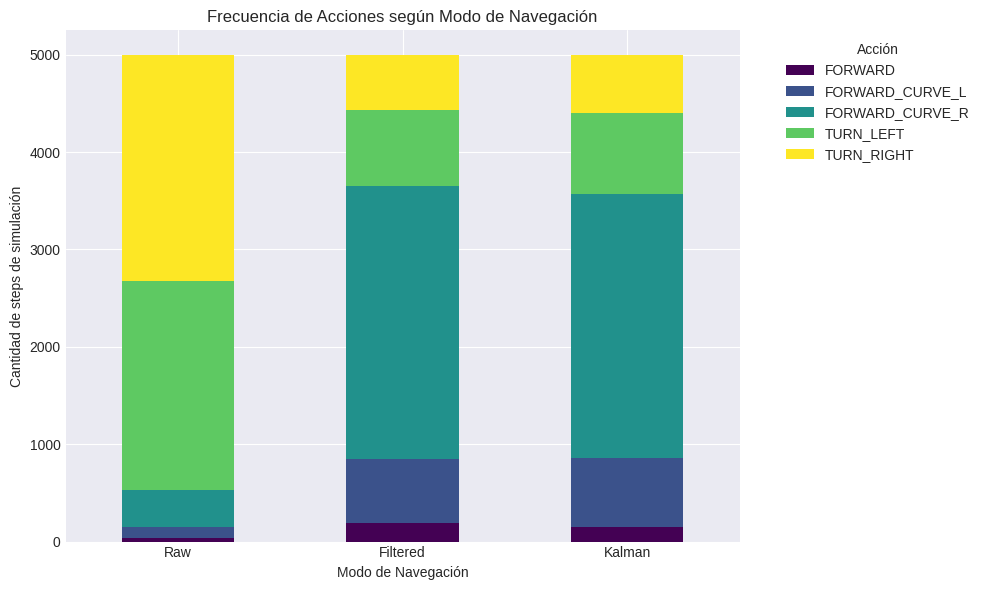

In [6]:
# Analizamos el conteo de acciones en los tres acercamientos
actions_raw = df_raw['action'].value_counts()
actions_filt = df_filt['action'].value_counts()
actions_kalman = df_kalman['action'].value_counts()

df_actions = pd.DataFrame({
    'Raw': actions_raw,
    'Filtered': actions_filt,
    'Kalman': actions_kalman
}).fillna(0)

display(df_actions)

df_actions.T.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title('Frecuencia de Acciones según Modo de Navegación')
plt.ylabel('Cantidad de steps de simulación')
plt.xlabel('Modo de Navegación')
plt.xticks(rotation=0)
plt.legend(title='Acción', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Evolución de Parámetros del Filtro de Kalman
La Ganancia de Kalman ($K$) y la Covarianza estimada ($P$) se ajustan dinámicamente frente al ruido del proceso ($Q$) y la varianza de medición sensada ($R$).

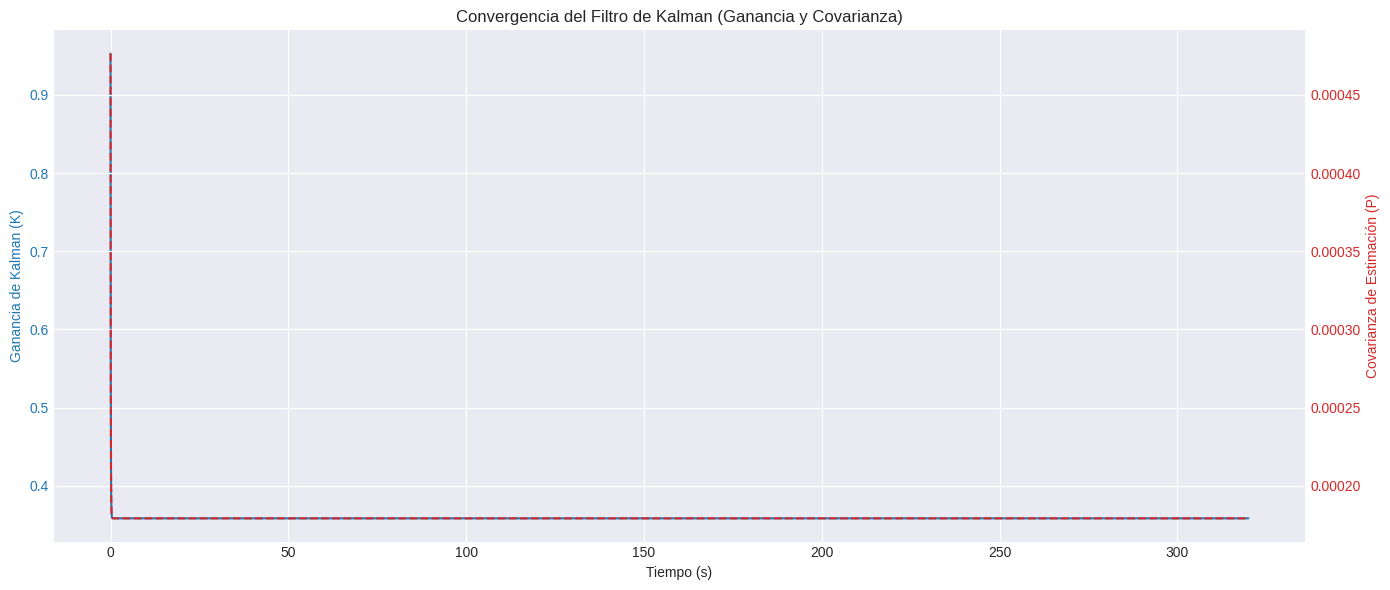

In [7]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Ganancia de Kalman (K)', color=color)
ax1.plot(df_kalman['time_s'], df_kalman['kalman_gain'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Covarianza de Estimación (P)', color=color)
ax2.plot(df_kalman['time_s'], df_kalman['kalman_P'], color=color, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Convergencia del Filtro de Kalman (Ganancia y Covarianza)')
fig.tight_layout()
plt.show()

# 5 Análisis general del escenario simple

El escenario evaluado corresponde a un entorno simple para el robot e-puck, compuesto únicamente por cuatro obstáculos. Debido a la baja complejidad del entorno, el robot no enfrenta cambios bruscos ni situaciones altamente dinámicas, permitiendo analizar principalmente el impacto del ruido sensorial y de los métodos de filtrado sobre el desempeño del controlador.

En términos generales, el robot logra desplazarse de manera estable y mantener una distancia segura respecto a los obstáculos. Sin embargo, las diferencias entre los modos de ejecución Raw, Filtered y Kalman muestran claramente cómo la calidad de las mediciones afecta directamente el comportamiento de navegación autónoma.

1.- **MODO RAW**

El modo Raw utiliza directamente las mediciones entregadas por los sensores sin aplicar procesamiento adicional. En la gráfica de distancia frontal se observa una señal altamente ruidosa, con múltiples picos y oscilaciones bruscas entre muestras consecutivas.

Las lecturas fluctúan aproximadamente entre 0.058 m y 0.12 m, evidenciando la sensibilidad de los sensores infrarrojos del e-puck al ruido y pequeñas perturbaciones del entorno.

Como consecuencia, el controlador reacciona excesivamente ante pequeñas variaciones, generando:
- Cambios frecuentes de dirección.
- Mayor cantidad de giros bruscos.
- Trayectorias menos suaves y más erráticas.

Esto se confirma en la gráfica de frecuencia de acciones, donde predominan las acciones TURN_LEFT y TURN_RIGHT, mientras que los movimientos curvos son poco frecuentes.

En general, el modo Raw presenta una navegación reactiva e inestable, donde pequeñas fluctuaciones son interpretadas como obstáculos reales.

2.- **MODO FILTERED**

El modo Filtered aplica un filtro de promedio móvil sobre las mediciones de distancia frontal. Este filtrado reduce considerablemente las oscilaciones rápidas y elimina gran parte del ruido presente en la señal original.

La señal resultante es más continua y estable, permitiendo que el controlador reciba información más consistente del entorno.

Como resultado:
- Disminuyen las correcciones bruscas.
- Aumentan los movimientos curvos suaves.
- La navegación se vuelve más fluida y natural.

En la gráfica de frecuencia de acciones se observa un incremento importante de FORWARD_CURVE_R y FORWARD_CURVE_L, indicando que el robot puede mantener trayectorias continuas sin realizar correcciones agresivas constantemente.

Sin embargo, el promedio móvil introduce cierto retraso temporal, suavizando también cambios rápidos del entorno y generando pequeños desfases respecto a la señal original.

3.- **MODO KALMAN**

El modo Kalman utiliza un filtro de Kalman para estimar la distancia frontal a partir de las mediciones ruidosas.

La señal obtenida presenta:
- Alta estabilidad.
- Reducción significativa del ruido.
- Conservación de las tendencias reales del sistema.
- Mejor equilibrio entre suavidad y capacidad de respuesta.

A diferencia del promedio móvil, el filtro de Kalman incorpora un modelo predictivo, permitiendo estimaciones más robustas y adaptativas.

Como consecuencia:
- El robot mantiene trayectorias más naturales.
- Disminuyen las oscilaciones innecesarias.
- Se logra una navegación más eficiente y consistente.

La gráfica de frecuencia de acciones muestra nuevamente predominio de movimientos curvos suaves, aunque con un comportamiento más equilibrado y estable que en el modo Filtered.

CONVERGENCIA DEL FILTRO DE KALMAN

La gráfica de convergencia muestra que tanto la ganancia de Kalman como la covarianza de estimación convergen rápidamente hacia valores estables.

Esto indica que:
- El filtro aprende rápidamente la incertidumbre del sistema.
- Las estimaciones se estabilizan en poco tiempo.
- El modelo logra adaptarse eficientemente al entorno.

La rápida convergencia es coherente con las características del escenario simple, donde existen pocos obstáculos y baja variabilidad dinámica.



# Conclusión

Los resultados demuestran que el uso de técnicas de filtrado mejora significativamente el desempeño de navegación autónoma del robot e-puck, incluso en escenarios simples.

El modo Raw evidencia cómo el ruido sensorial puede afectar negativamente el comportamiento del controlador, generando movimientos erráticos y correcciones innecesarias.

Por otro lado, tanto el filtro promedio móvil como el filtro de Kalman permiten una navegación más suave y confiable. Sin embargo, el filtro de Kalman presenta el mejor desempeño general, debido a su capacidad de reducir ruido manteniendo simultáneamente una buena capacidad de adaptación y respuesta.

Finalmente, el escenario simple demuestra que el controlador implementado es funcional y capaz de mantener la distancia de seguridad cercana al umbral definido de 0.06 m sin presentar comportamientos inestables significativos.